In [407]:

import numpy as np
import os
from sklearn.model_selection import train_test_split, StratifiedKFold
from keras.utils import to_categorical
from sklearn import metrics
import tensorflow as tf

In [ ]:
data_dir = "processed_data"
output_model_path = "model_lstm_40.h5"

test_size = 0.10
random_state = 42

# Параметры обучения
epochs = 400
dropout_rate= 0.5
frames = 20
num_features = 126

In [409]:
actions = []
for item in os.listdir(data_dir):
    item_path = os.path.join(data_dir, item)
    if os.path.isdir(item_path):
        actions.append(item)

actions = np.array(actions)
num_classes = len(actions)
print(f"Найдено {num_classes} слов.")

Найдено 60 слов.


In [410]:
# Загрузка последовательностей
first_word_dir = os.path.join(data_dir, actions[0])
sequences_dirs = [d for d in os.listdir(first_word_dir) if os.path.isdir(os.path.join(first_word_dir, d))]
sequences = len(sequences_dirs)

label_map = {label: num for num, label in enumerate(actions)}
landmarks, labels = [], []

In [411]:
# Загрузка данных
for action in actions:
    action_dir = os.path.join(data_dir, action)
    sequence_dirs = [d for d in os.listdir(action_dir) if os.path.isdir(os.path.join(action_dir, d))]
    
    for sequence in sequence_dirs:
        sequence_path = os.path.join(action_dir, sequence)
        
        if not os.path.exists(sequence_path):
            continue
            
        temp = []
        frame_files = sorted([f for f in os.listdir(sequence_path) if f.endswith('.npy')], 
                            key=lambda x: int(x.split('.')[0]))
        
        for frame_file in frame_files:
            frame_path = os.path.join(sequence_path, frame_file)
            try:
                npy = np.load(frame_path)
                temp.append(npy)
            except Exception as e:
                print(f"Ошибка загрузки {frame_path}: {e}")

        if len(temp) == frames:
            landmarks.append(temp)
            labels.append(label_map[action])

In [ ]:
X = np.array(landmarks)
Y = to_categorical(labels).astype(int)

print(f"Начальные размеры данных: X shape: {X.shape}, Y shape: {Y.shape}")

def augment_data(X, Y, noise_factor=0.02):
    X_aug = []
    Y_aug = []
    
    for i in range(len(X)):
        X_aug.append(X[i])
        Y_aug.append(Y[i])
        
        # Добавляем шум
        noise = np.random.normal(0, noise_factor, X[i].shape)
        X_aug.append(X[i] + noise)
        Y_aug.append(Y[i])
    
    return np.array(X_aug), np.array(Y_aug)

X, Y = augment_data(X, Y)

# Нормализация
X_mean = X.mean(axis=(0, 1), keepdims=True)
X_std = X.std(axis=(0, 1), keepdims=True)
X = (X - X_mean) / (X_std + 1e-8)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=random_state, stratify=Y)

Начальные размеры данных: X shape: (1277, 20, 126), Y shape: (1277, 60)


In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from keras.layers import Activation, GlobalAveragePooling1D, GaussianNoise
from keras import regularizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.optimizers import Adam

model = Sequential()

model.add(GaussianNoise(0.02, input_shape=(frames, num_features)))

model.add(Bidirectional(LSTM(64, return_sequences=True, 
                            activation='tanh',
                            recurrent_dropout=0.3,
                            kernel_regularizer=regularizers.l2(0.002))))
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))

# 2. Второй слой тоже меньше
model.add(Bidirectional(LSTM(128, return_sequences=True,
                            activation='tanh',
                            recurrent_dropout=0.3,
                            kernel_regularizer=regularizers.l2(0.002)))) 
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))

# 3. Глобальный пулинг
model.add(GlobalAveragePooling1D())
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))

# 4. Полносвязные слои
model.add(Dense(128, kernel_regularizer=regularizers.l1_l2(l1=0.002, l2=0.002)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))

model.add(Dense(64, kernel_regularizer=regularizers.l1_l2(l1=0.002, l2=0.002)))
model.add(Activation('relu'))
model.add(BatchNormalization()) 
model.add(Dropout(dropout_rate))

# Выходной слой
model.add(Dense(num_classes, activation='softmax'))

optimizer = Adam(
    learning_rate=0.0001,
    clipnorm=1.0,       
    beta_1=0.9,          
    beta_2=0.999,
    epsilon=1e-7
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,  
        patience=6, 
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_no_overfit.h5',
        monitor='val_categorical_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

c:\Users\pvlmakarova\anaconda3\envs\diploma_env\lib\site-packages\keras\src\layers\regularization\gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_11               │ (None, 20, 126)        │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_46                │ (None, 20, 128)        │        97,792 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_108         │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_126 (Dropout)           │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_47                │ (None, 20, 256)        │       263,168 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_109         │ (None, 20, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_127 (Dropout)           │ (None, 20, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_22     │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_110         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_128 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_45 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_111         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_129 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_46 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_112         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_130 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 60)             │         3,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 409,340 (1.56 MB)

 Trainable params: 407,676 (1.56 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [ ]:
# Обучение модели
import time
start_time = time.time()

history = model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=epochs,
    batch_size=32,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

In [417]:
# Время обучения
training_time = time.time() - start_time
hours, remainder = divmod(training_time, 3600)
minutes, seconds = divmod(remainder, 60)
print(f"Время обучения модели LSTM: {int(hours)} ч {int(minutes)} мин {int(seconds)} сек")

Время обучения модели LSTM: 0 ч 10 мин 8 сек


In [422]:
# Оценка модели
predictions = np.argmax(model.predict(X_test), axis=1)
test_labels = np.argmax(Y_test, axis=1)

accuracy = metrics.accuracy_score(test_labels, predictions)
print(f"Точность модели на тестовой выборке: {accuracy:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Точность модели на тестовой выборке: 0.9141


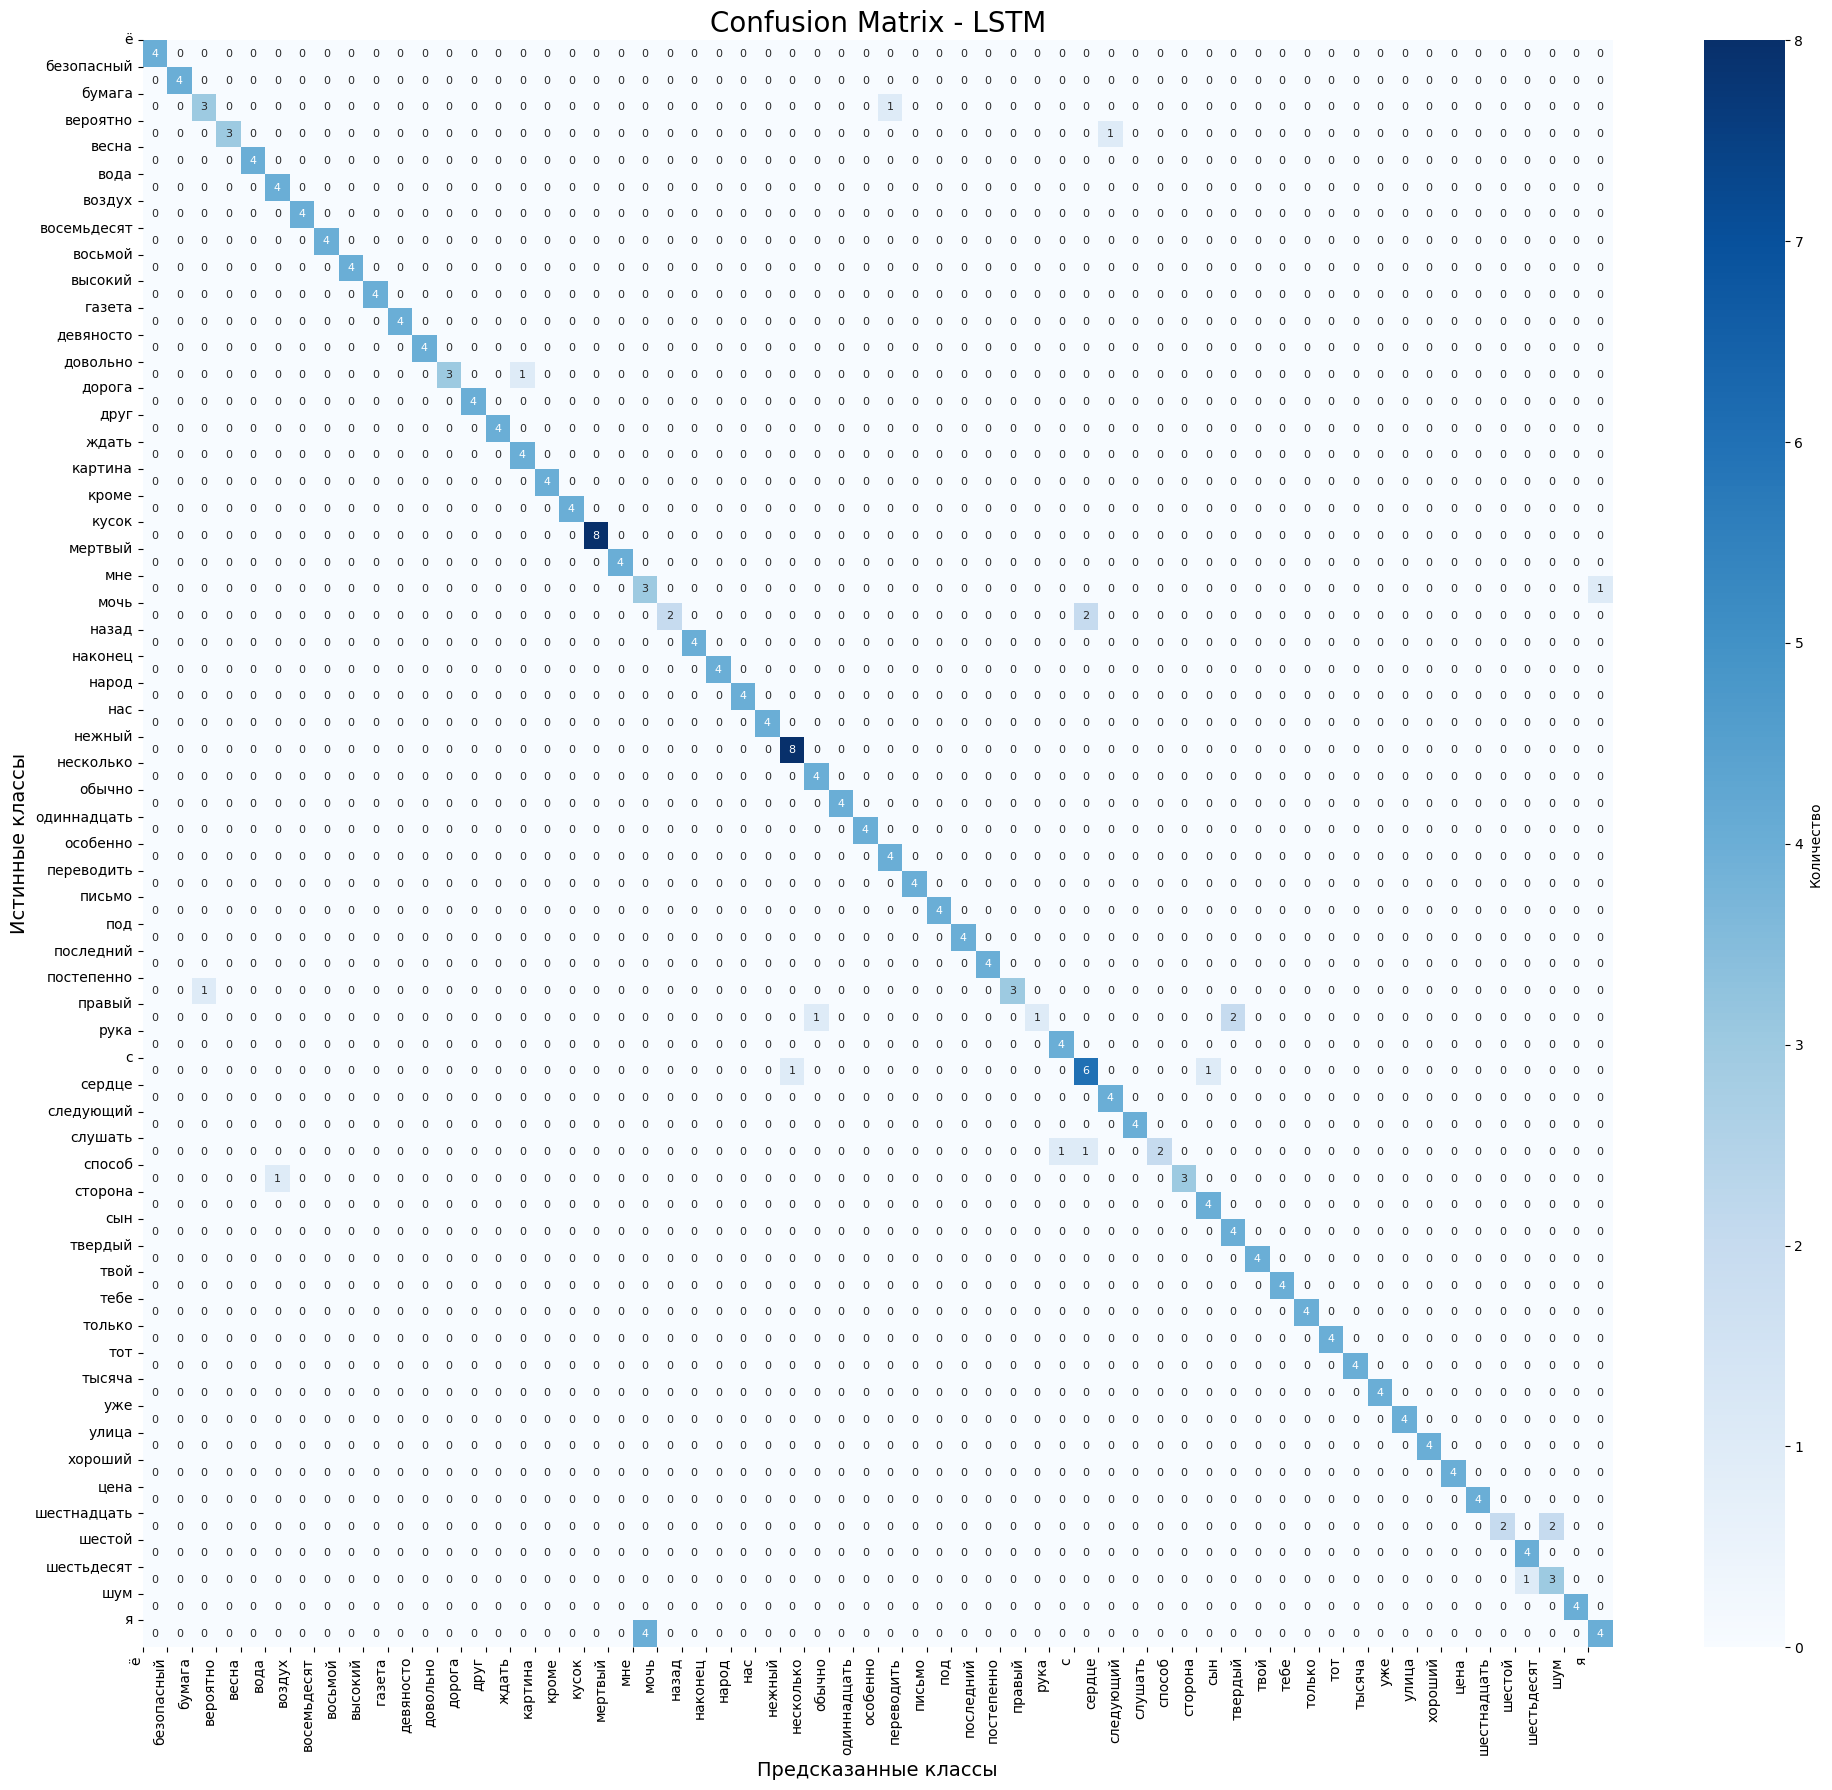

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

plt.figure(figsize=(20, 18))
cm = confusion_matrix(test_labels, predictions)
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar_kws={'label': 'Количество'},
            annot_kws={'size': 8})
plt.title('Confusion Matrix - LSTM', fontsize=20)
plt.xlabel('Предсказанные классы', fontsize=14)
plt.ylabel('Истинные классы', fontsize=14)
plt.xticks(range(len(actions)), actions, rotation=90, ha='right')
plt.yticks(range(len(actions)), actions, rotation=0)
plt.tight_layout()
plt.show()

In [420]:
cr = metrics.classification_report(test_labels, predictions, 
                                    target_names=actions, 
                                    digits=3)
print("\nОтчет о классификации:")
print(cr)


Отчет о классификации:
              precision    recall  f1-score   support

           ё      1.000     1.000     1.000         4
  безопасный      1.000     1.000     1.000         4
      бумага      0.750     0.750     0.750         4
    вероятно      1.000     0.750     0.857         4
       весна      1.000     1.000     1.000         4
        вода      0.800     1.000     0.889         4
      воздух      1.000     1.000     1.000         4
 восемьдесят      1.000     1.000     1.000         4
     восьмой      1.000     1.000     1.000         4
     высокий      1.000     1.000     1.000         4
      газета      1.000     1.000     1.000         4
   девяносто      1.000     1.000     1.000         4
    довольно      1.000     0.750     0.857         4
      дорога      1.000     1.000     1.000         4
        друг      1.000     1.000     1.000         4
       ждать      0.800     1.000     0.889         4
     картина      1.000     1.000     1.000         4
   

In [ ]:
model.save(output_model_path)

class_mapping = {i: word for i, word in enumerate(actions)}
np.save('class_mapping.npy', class_mapping)

with open('class_mapping.txt', 'w', encoding='utf-8') as f:
    for i, word in enumerate(actions):
        f.write(f"{i}: {word}\n")
